In [1]:
# ─────────────────────────────────────────────
# [C1] ◀ ⚙️ 데이터 준비
# 최초 1회 다운로드 → data/ 폴더에 저장 (이후 오프라인)
# ─────────────────────────────────────────────
import urllib.request, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

def fetch_uci(url, zip_name, member):
    """UCI 정적 저장소의 zip을 내려받아 data/에 풀고, CSV 경로를 돌려줍니다."""
    csv_path = DATA_DIR / member
    if not csv_path.exists():
        zip_path = DATA_DIR / zip_name
        if not zip_path.exists():
            print(f"내려받는 중… {zip_name}")
            urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path) as z:
            z.extract(member, DATA_DIR)
    return csv_path

shoppers = pd.read_csv(fetch_uci(
    "https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip",
    "online_shoppers.zip", "online_shoppers_intention.csv"))

# 지난 순서와 동일한 수치형 10개 열 — 비교의 조건을 고정합니다
NUM_COLS = ["Administrative", "Administrative_Duration", "Informational",
            "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
            "BounceRates", "ExitRates", "PageValues", "SpecialDay"]

print(f"쇼핑 세션 데이터: {shoppers.shape[0]:,}행 × {shoppers.shape[1]}열")
print(f"구매 전환율: {shoppers['Revenue'].mean():.4f}")
print("\n→ 준비 완료. 이제 여러분 차례입니다.")

쇼핑 세션 데이터: 12,330행 × 18열
구매 전환율: 0.1547

→ 준비 완료. 이제 여러분 차례입니다.


[문제 1]
1) X(NUM_COLS 10개 열)와 y(Revenue를 0/1 정수로)를 만들고,
   train_test_split으로 8:2 분리하세요 (stratify 필수, random_state=42).
2) 세 모델을 학습시켜 학습 정확도 · 테스트 정확도 · 그 격차를 한 표로 출력하세요.
   ① DummyClassifier(strategy="most_frequent")
   ② LogisticRegression(max_iter=1000)  ← 스케일링 필요
   ③ DecisionTreeClassifier()           ← 기본 설정, 깊이 제한 없음

In [136]:
# [C2] ◀ 문제 1. 단일 트리를 얹어 본다
# ⌨️ 문제 1 — 베이스라인 · 로지스틱 · 단일 트리를 나란히
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 여기에 코드를 작성하세요 (X, y 준비 → 분리 → 세 모델 학습 → 학습·테스트·격차 표)

#X, y 준비 
X = shoppers[NUM_COLS]
y = shoppers["Revenue"].astype(int)

# 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20%를 테스트용으로
    random_state=42, 
    stratify=y,       # 클래스 비율 유지 (분류에서 중요!)
)
print(f"전체 데이터: {len(X):,}명")
print(f"  학습용(train): {len(X_train):,}명  ({len(X_train)/len(X)*100:.0f}%)")
print(f"  테스트용(test): {len(X_test):,}명  ({len(X_test)/len(X)*100:.0f}%)")
print()

# ① DummyClassifier(strategy="most_frequent") 학습 [베이스라인]
dum_clf = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
base_train = dum_clf.score(X_train, y_train) # 학습 정확도
base_acc = dum_clf.score(X_test, y_test)   # 테스트 정확도
# Dummy는 X 값을 무시하므로 스케일링 불필요
print(f"  베이스라인(무조건 다수) 학습 정확도 = {base_train:.3f}")
print(f"  베이스라인(무조건 다수) 테스트 정확도 = {base_acc:.3f}")


# = ② LogisticRegression(max_iter=1000) + 스케일링 학습 [로지스틱 회귀]
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # 학습 데이터로만 기준을 잡고
X_test_s = scaler.transform(X_test)         # 같은 기준으로 테스트 변환 (누수 방지!)
clf = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
clf.fit(X_train_s, y_train)

from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = clf.predict(X_test_s)              # 예/아니오 예측
y_proba = clf.predict_proba(X_test_s)[:, 1] # 1(이탈)일 확률

acc = accuracy_score(y_test, y_pred)
# print(f"테스트 정확도(Accuracy) = {acc:.3f}") 이게 뭐지

print()
# 로지스틱 회귀(이탈): 학습 정확도 vs 테스트 정확도
acc_train = clf.score(X_train_s, y_train) # 학습 정확도
acc_test = clf.score(X_test_s, y_test)    # 테스트 정확도
print(f"  로지스틱 회귀 학습 정확도 = {acc_train:.3f}")
print(f"  로지스틱 회귀 테스트 정확도 = {acc_test:.3f}")



print()
tree = DecisionTreeClassifier(random_state=42) # ← 기본 설정, 깊이 제한 없음
tree.fit(X_train, y_train)
print(f"  의사결정나무 학습 정확도 = {tree.score(X_train, y_train):.3f}")
print(f"  의사결정나무 테스트 정확도 = {tree.score(X_test, y_test):.3f}")


전체 데이터: 12,330명
  학습용(train): 9,864명  (80%)
  테스트용(test): 2,466명  (20%)

  베이스라인(무조건 다수) 학습 정확도 = 0.845
  베이스라인(무조건 다수) 테스트 정확도 = 0.845

  로지스틱 회귀 학습 정확도 = 0.884
  로지스틱 회귀 테스트 정확도 = 0.880

  의사결정나무 학습 정확도 = 1.000
  의사결정나무 테스트 정확도 = 0.842


In [137]:
rows = {"베이스라인": {"학습 정확도": base_train, "테스트 정확도": base_acc, "격차": base_train - base_acc}, 
        "로지스틱 회귀": {"학습 정확도": acc_train, "테스트 정확도": acc_test, "격차": acc_train - acc_test}, 
        "의사결정나무": {"학습 정확도": tree.score(X_train, y_train), "테스트 정확도": tree.score(X_test, y_test), "격차": tree.score(X_train, y_train) - tree.score(X_test, y_test)}
        }
print("\n모델별 학습·테스트 정확도 비교")
models = pd.DataFrame(rows).T
models


모델별 학습·테스트 정확도 비교


,학습 정확도,테스트 정확도,격차
베이스라인,0.845296,0.845093,0.000203
로지스틱 회귀,0.883921,0.879562,0.004359
의사결정나무,0.999797,0.842255,0.157543


계속 의사결정나무 값이 정답이랑 안 맞아서 뭐지? 싶었는데
기본 설정을 안하고 max_depth=3  해서 오류가 난 거엿음

알고 나니 쉽네 ㅋㅋ


[문제 2]
1) max_depth를 [2, 3, 5, 8, 12, None]으로 바꿔가며 트리를 학습시키고,
   각 깊이의 학습 정확도 · 테스트 정확도 · 격차를 표로 출력하세요.
2) 테스트 정확도가 가장 높은 깊이를 찾아 출력하세요.
3) 깊이에 따라 학습 점수와 테스트 점수가 어떻게 갈라지는지 선 그래프로 그리세요.

In [138]:
# [C3] ◀ 문제 2. 가지치기로 격차를 줄인다
# ⌨️ 문제 2 — max_depth를 훑어 과적합을 통제하기

# 여기에 코드를 작성하세요 (깊이별 학습·테스트·격차 표 → 최고 깊이 → 선 그래프)

## 깊이별 학습·테스트·격차 표 
tr, te = [], []
depths = [2, 3, 5, 8, 12, None] # None은 깊이 제한 없음
for depth in depths:
    m = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE).fit(X_train, y_train)
    tr.append(m.score(X_train, y_train)); te.append(m.score(X_test, y_test))

    # tr <- 학습 데이터 정확도
# te <- 테스트 데이터 정확도
# tr - te <- 격차

max_depths = {"학습 정확도": tr, "테스트 정확도": te, "격차": [t - e for t, e in zip(tr, te)]}
print("\n 각 깊이의 학습 정확도 · 테스트 정확도 · 격차")
zz = pd.DataFrame(max_depths, index=[str(depth) for depth in depths])
zz


 각 깊이의 학습 정확도 · 테스트 정확도 · 격차


,학습 정확도,테스트 정확도,격차
2,0.892234,0.886050,0.006184
3,0.893248,0.883212,0.010036
5,0.904907,0.894161,0.010746
8,0.925284,0.888078,0.037206
12,0.957218,0.874696,0.082522
None,0.999797,0.842255,0.157543


In [139]:
print("\n테스트 정확도가 가장 높은 깊이")
zz.loc[zz["테스트 정확도"].idxmax()]



테스트 정확도가 가장 높은 깊이


학습 정확도     0.904907
테스트 정확도    0.894161
격차         0.010746
Name: 5, dtype: float64

C:\Users\tjwls\AppData\Local\Temp\ipykernel_18452\2666136470.py:13: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout(); plt.show()
C:\Users\tjwls\AppData\Local\Temp\ipykernel_18452\2666136470.py:13: UserWarning: Glyph 51105 (\N{HANGUL SYLLABLE JAB}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout(); plt.show()
C:\Users\tjwls\AppData\Local\Temp\ipykernel_18452\2666136470.py:13: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout(); plt.show()
C:\Users\tjwls\AppData\Local\Temp\ipykernel_18452\2666136470.py:13: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout(); plt.show()
C:\Users\tjwls\AppData\Local\Temp\ipykernel_18452\2666136470.py:13: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout(); plt.show(

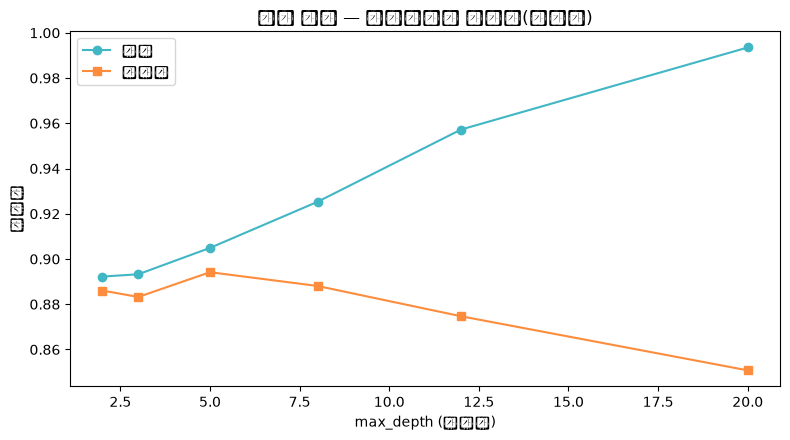

In [140]:
tr, te = [], []
depths = [2, 3, 5, 8, 12, 20] #그래프 표시
for depth in depths:
    m = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE).fit(X_train, y_train)
    tr.append(m.score(X_train, y_train)); te.append(m.score(X_test, y_test))


plt.figure(figsize=(8, 4.5))
plt.plot(list(depths), tr, "o-", label="학습", color="#41b6c4")
plt.plot(list(depths), te, "s-", label="테스트", color="#fd8d3c")
plt.xlabel("max_depth (복잡도)"); plt.ylabel("정확도")
plt.title("단일 트리 — 깊어질수록 외운다(과적합)")
plt.legend(); plt.tight_layout(); plt.show()

[문제 3]
1) 두 모델을 추가로 학습시켜 같은 형식(학습·테스트·격차)으로 표에 넣으세요.
   ④ RandomForestClassifier(n_estimators=300)
   ⑤ XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=4, reg_lambda=1.0)
2) 문제 1·2의 결과와 합쳐 최종 비교표를 테스트 정확도 내림차순으로 출력하세요.
3) 표를 보고 "팀장께 무엇을 보고할 것인가"를 두세 문장으로 적어 보세요.

In [141]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ④ RandomForestClassifier(n_estimators=300)
rf = RandomForestClassifier(n_estimators=300, n_jobs=-1).fit(X_train, y_train)
print("랜덤포레스트 : 학습 {:.3f} / 테스트 {:.3f}".format(rf.score(X_train, y_train), rf.score(X_test, y_test)))

xgb = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=4,
                    reg_lambda=1.0, eval_metric="logloss")
xgb.fit(X_train, y_train)
print(f"XGBoost 학습 정확도 = {xgb.score(X_train, y_train):.3f}")
print(f"XGBoost 테스트 정확도 = {xgb.score(X_test, y_test):.3f}")

랜덤포레스트 : 학습 1.000 / 테스트 0.896
XGBoost 학습 정확도 = 0.945
XGBoost 테스트 정확도 = 0.887


In [142]:
models.loc["랜덤포레스트"] = {"학습 정확도": rf.score(X_train, y_train), "테스트 정확도": rf.score(X_test, y_test), "격차": rf.score(X_train, y_train) - rf.score(X_test, y_test)}
models.loc["XGBoost"] = {"학습 정확도": xgb.score(X_train, y_train), "테스트 정확도": xgb.score(X_test, y_test), "격차": xgb.score(X_train, y_train) - xgb.score(X_test, y_test)}
models.loc["의사결정나무 (max_depth=5)"] = zz.loc[zz["테스트 정확도"].idxmax()]
models.sort_values("테스트 정확도", ascending=False)

,학습 정확도,테스트 정확도,격차
랜덤포레스트,0.999797,0.895783,0.104015
의사결정나무 (max_depth=5),0.904907,0.894161,0.010746
XGBoost,0.945053,0.887267,0.057786
로지스틱 회귀,0.883921,0.879562,0.004359
베이스라인,0.845296,0.845093,0.000203
의사결정나무,0.999797,0.842255,0.157543


"팀장께 무엇을 보고할 것인가"


요즘 다들 쓴다는 XGBoost 같은 걸로 바꾸면 로지스틱 회귀보다 정확도가 0.08 더 좋아집니다. 

[문제 4]
1) 랜덤포레스트의 피처 중요도를 내림차순으로 그리세요 (가로 막대, 10개 전부).
2) 상위 3개 피처에 대해, 값이 큰 세션과 작은 세션의 구매율을 실제로 비교하세요.
   (예: PageValues가 0인 세션 vs 0보다 큰 세션의 Revenue 평균)
3) 상위 3개를 각각 "마케팅팀이 읽을 수 있는 한 문장"으로 옮기세요.
   그리고 이 중요도로 답할 수 없는 것이 무엇인지 한 줄 적으세요.

C:\Users\tjwls\AppData\Local\Temp\ipykernel_18452\3868742872.py:6: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\tjwls\AppData\Local\Temp\ipykernel_18452\3868742872.py:6: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\tjwls\AppData\Local\Temp\ipykernel_18452\3868742872.py:6: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\tjwls\AppData\Local\Temp\ipykernel_18452\3868742872.py:6: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\tjwls\AppData\Local\Temp\ipykernel_18452\3868742872.py:6: UserWarning: Glyph 49692 (\N{HANGUL SYLLABLE SUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\tjwls\AppData\Local\Temp\ipykernel_18452\3868742872.py:6: UserWarni

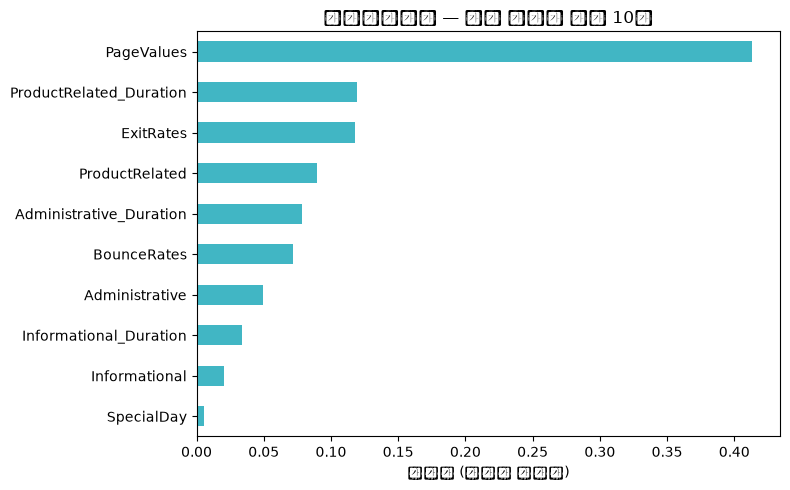

가장 중요한 피처 Top 3:
PageValues                 0.413330
ProductRelated_Duration    0.119399
ExitRates                  0.117769
dtype: float64


In [144]:
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(8, 5))
imp[::-1].plot(kind="barh", color="#41b6c4")
plt.title("랜덤포레스트 — 피처 중요도 상위 10개")
plt.xlabel("중요도 (불순도 감소량)")
plt.tight_layout(); plt.show()
print("가장 중요한 피처 Top 3:")
print(imp.head(3))

PageValues  페이지 방문이 클수록 구매 확률이 늘어남. 
제품관련_기간 이 길수록 구매 확률이 늘어남



In [ ]:
# PageValues
shoppers.groupby(shoppers['PageValues']==0)["Revenue"].agg(["mean", "size"])
# PageValues == 0인 세션의 구매 전환율 0.03, 1인 세션의 구매 전환율은 0.56, 
# 3% vs 56%로 큰 차이가 난다. PageValues가 0인 세션은 구매 전환율이 매우 낮다.

,mean,size
PageValues,,
False,0.563370,2730
True,0.038542,9600


In [ ]:
# ExitRates 
shoppers.groupby(shoppers['ExitRates'] >= shoppers['ExitRates'].median())["Revenue"].agg(["mean", "size"])
# ExitRates가 중간값 이상인 세션의 구매 전환율은 0.07, 중간값 미만인 세션의 구매 전환율은 0.23,
# 7% vs 23%로 차이가 난다. ExitRates가 중간값 이상인 세션은 구매 전환율이 낮다.

# ExitRates는 방향이 반대(값이 높을수록 구매율이 낮음)

,mean,size
ExitRates,,
False,0.235199,6165
True,0.074290,6165


In [162]:
# ProductRelated_Duration
shoppers.groupby(shoppers['ProductRelated_Duration'] >= shoppers['ProductRelated_Duration'].median())["Revenue"].agg(["mean", "size"])
# ProductRelated_Duration이 중간값 이상인 세션의 구매 전환율은 0.2, 중간값 미만인 세션의 구매 전환율은 0.08,
# 20% vs 8%로 큰 차이가 난다. ProductRelated_Duration이 길수록 구매 전환율이 높다.

,mean,size
ProductRelated_Duration,,
False,0.086618,6165
True,0.222871,6165


[문제 5]
1) 최종 비교표를 파일로 남기세요 — model_comparison_v2.csv
2) 아래 모델 카드 v2 템플릿의 빈칸을 여러분의 숫자와 문장으로 채우세요.
   특히 '선택한 모델과 근거'는 성능·해석력·비용 중 무엇을 우선했는지 밝혀야 합니다.

In [163]:
models.to_csv("c:\\Users\\tjwls\\OneDrive\\문서\\ai-data-bootcamp\\D020\\model_comparison_v2.csv")